In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Housing.csv to Housing.csv


# Task 1: Data Loading & Exploration

**Objective:** Load and explore the housing dataset to understand its structure, features, and target variable.

**Summary:** The dataset was loaded using Pandas, and its shape, columns, missing values, and duplicate records were examined. The target variable identified for prediction is `price`.

In [3]:
df = pd.read_csv("Housing.csv")

print("Dataset Shape:", df.shape)

df.head(10)

Dataset Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (545, 13)

Column Names:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea       

In [6]:
target = "price"
features = [col for col in df.columns if col != target]

print("Target Variable:", target)
print("Features:")
print(features)

Target Variable: price
Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


# Task 2: Data Cleaning & Preprocessing

**Objective:** Prepare the dataset for machine learning by cleaning and transforming the data.

**Summary:** Duplicate records were checked and categorical variables were converted into numerical form using one-hot encoding. The cleaned dataset was then prepared for model training.

In [7]:
# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

# Check missing values again
print("\nMissing Values:")
print(df.isnull().sum())

Shape after removing duplicates:
(545, 13)

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [8]:
df_clean = pd.get_dummies(
    df,
    drop_first=True
)

print(df_clean.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

In [9]:
print(df_clean.shape)
print(df_clean.columns)

(545, 14)
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


## Task 3: Model Building

Objective:
Build and compare Linear Regression and Random Forest Regressor models for predicting house prices.
The dataset is split into training and testing sets using an 80:20 ratio.

In [12]:
X = df_clean.drop("price", axis=1)
y = df_clean["price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (436, 13)
Testing Samples: (109, 13)


In [14]:
X_train = X_train.astype(int)
X_test = X_test.astype(int)

In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

Linear Regression Results
-------------------------
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

In [18]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
---------------------
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2 Score": [
        r2_lr,
        r2_rf
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


## Task 4: Data Visualization

Objective:
Visualize the distribution of house prices and understand relationships between features and the target variable.

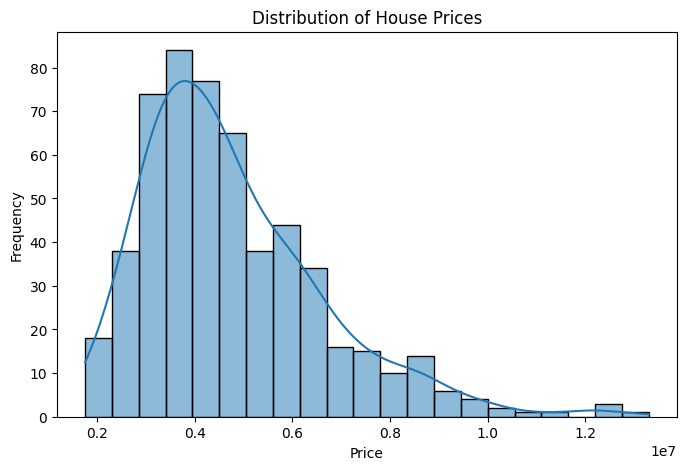

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("price_distribution.png")

plt.show()

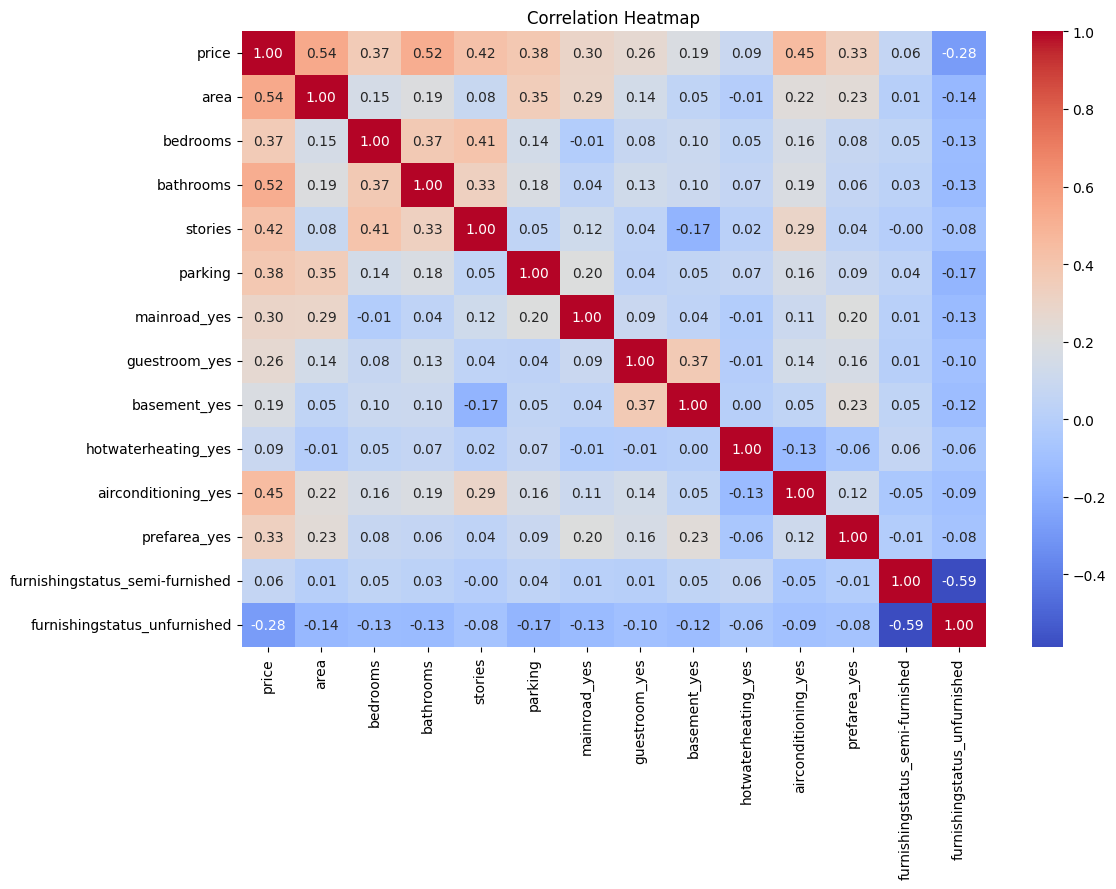

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()

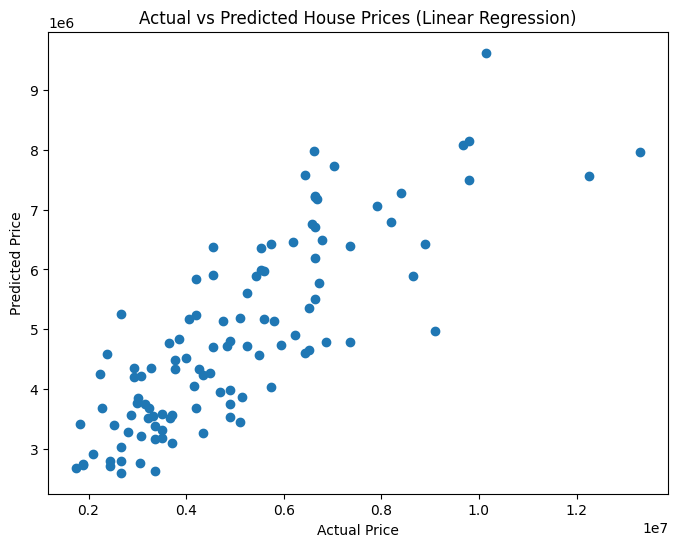

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lr
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted House Prices (Linear Regression)"
)

plt.savefig("actual_vs_predicted.png")

plt.show()

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


## Task 5: Insights & Summary

The objective of this project was to predict house prices using various property-related features. Two machine learning models, Linear Regression and Random Forest Regressor, were trained and evaluated. Linear Regression performed better with an R² Score of 0.653, indicating that it explained approximately 65.3% of the variation in house prices. Feature importance analysis showed that area was the most influential factor, followed by bathrooms, air conditioning, parking availability, and number of stories. The analysis revealed that larger houses with better amenities generally have higher prices. One interesting observation was that area alone contributed nearly half of the model's predictive power. Based on these findings, real estate businesses should focus on property size and key amenities when estimating property values and planning investments.